In [1]:
pip install qiskit

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
from joblib import Parallel, delayed
import time
import math
import pylatexenc

🔧 Paramètres de la fenêtre glissante SPATIALE:
  - Taille des blocs: 3 qubits
  - Chevauchement: 0 qubits
  - Seuil de validité: 0.05
  - Max ajustements: 10
🎯 Circuit Cible:


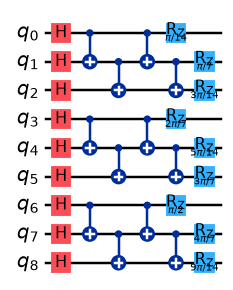


🚀 Démarrage de l'optimisation multi-objectifs avec découpage spatial...
Paramètres: 9 qubits, 18 gènes, 50 individus, 10 générations

Génération 1/10
Front de Pareto: 4 solutions
Fidélité: 0.0017 ± 0.0016
Profondeur: 3.50 ± 0.50
Coût: 23.75 ± 4.76

Génération 2/10
Front de Pareto: 3 solutions
Fidélité: 0.0038 ± 0.0028
Profondeur: 3.67 ± 0.47
Coût: 21.33 ± 4.03

Génération 3/10
Front de Pareto: 5 solutions
Fidélité: 0.0042 ± 0.0021
Profondeur: 3.40 ± 0.49
Coût: 19.60 ± 1.74

Génération 4/10
Front de Pareto: 6 solutions
Fidélité: 0.0060 ± 0.0033
Profondeur: 3.50 ± 0.50
Coût: 21.17 ± 4.02

Génération 5/10
Front de Pareto: 9 solutions
Fidélité: 0.0056 ± 0.0029
Profondeur: 3.22 ± 0.42
Coût: 20.67 ± 3.62

Génération 6/10
Front de Pareto: 8 solutions
Fidélité: 0.0052 ± 0.0041
Profondeur: 3.25 ± 0.43
Coût: 20.38 ± 5.02

Génération 7/10
Front de Pareto: 9 solutions
Fidélité: 0.0042 ± 0.0041
Profondeur: 3.22 ± 0.42
Coût: 18.00 ± 2.26

Génération 8/10
Front de Pareto: 14 solutions
Fidélité: 0.00

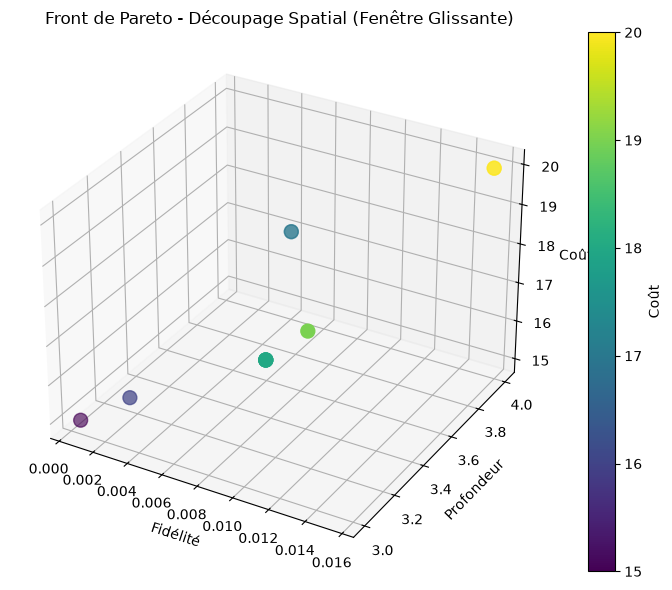

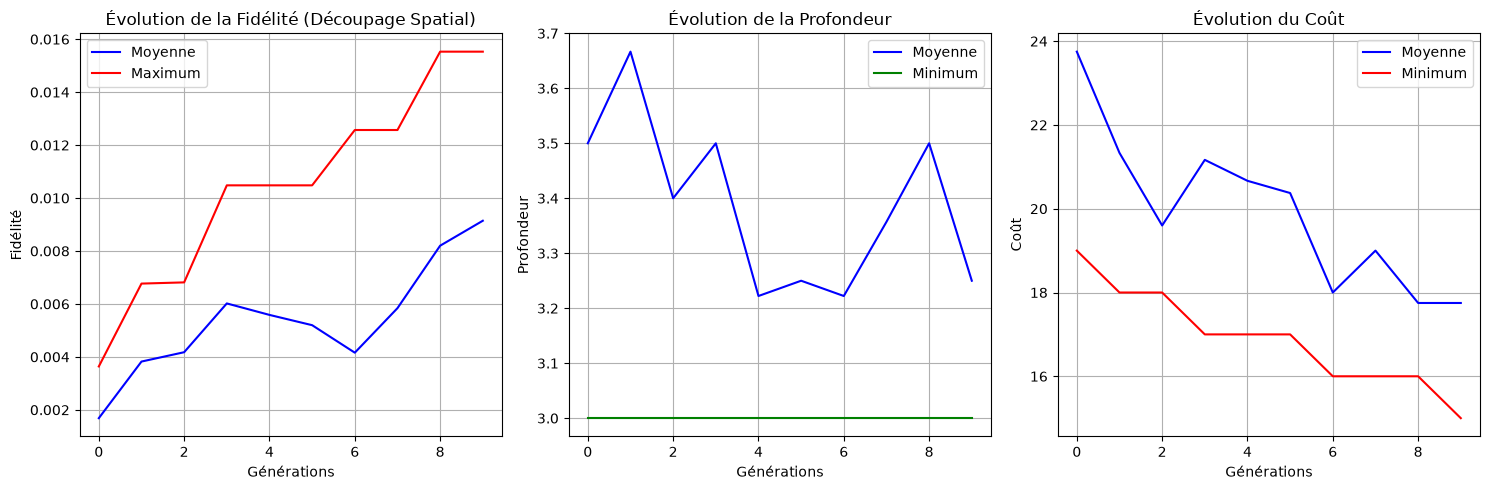


🏆 Meilleur circuit (fidélité) après ajustement:
Fidélité approx: 0.0155
Fidélité exacte:  0.0155
Profondeur: 4
Coût: 20
Circuit Optimisé:


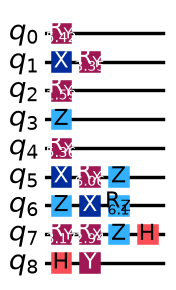


📈 Analyse du découpage spatial:
Solutions avant ajustement: 12
Solutions après ajustement: 12
Fidélité moyenne originale: 0.0088
Fidélité moyenne ajustée:   0.0088
Amélioration moyenne: 0.0000

✅ Avantages du découpage spatial:
  - Blocs cohérents par groupes de qubits
  - Distribution équilibrée de la charge
  - Respect de la topologie quantique
  - Fenêtre glissante avec chevauchement contrôlé


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from joblib import Parallel, delayed
import copy
from mpl_toolkits.mplot3d import Axes3D

# -------------------- Gate costs --------------------
GATE_COSTS = {
    'NOT': 1,
    'Phase': 1,
    'H': 2,      # Hadamard
    'X': 1,
    'Y': 1,
    'Z': 1,
    'CNOT': 5,
    'CX': 5,     # Equivalent to CNOT
    'SWAP': 11,
    'Peres': 12,
    'Toffoli': 13,
    'Fredkin': 19,
    'Miller': 24,
    'RX': 1,     # Rotation gates
    'RY': 1,
    'RZ': 1
}

# -------------------- Sliding window parameters --------------------
BLOCK_SIZE = 3  # Size of each block (number of qubits)
OVERLAP_SIZE = 0 # Overlap between blocks (number of qubits)
VALIDITY_THRESHOLD = 0.05  # Threshold for the validity test
MAX_ADJUSTMENT_ATTEMPTS = 10  # Max number of adjustment attempts

# -------------------- Class for the multi-objective individual --------------------
class MultiObjectiveIndividual:
    def __init__(self, chromosome, fitness_values=None):
        self.chromosome = chromosome
        self.fitness_values = fitness_values  # [fidelity, -depth, -cost]
        self.rank = None
        self.crowding_distance = 0
        self.dominated_by = []
        self.dominates = []

    def dominates_other(self, other):
        """Checks whether this individual dominates another (all objectives >= and at least one >)"""
        if self.fitness_values is None or other.fitness_values is None:
            return False

        better_in_all = all(self.fitness_values[i] >= other.fitness_values[i] for i in range(len(self.fitness_values)))
        better_in_at_least_one = any(self.fitness_values[i] > other.fitness_values[i] for i in range(len(self.fitness_values)))

        return better_in_all and better_in_at_least_one

# -------------------- Circuit generation --------------------
def generate_gene(num_qubits):
    """Generates a random gene representing a quantum gate."""
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]

def generate_chromosome(num_qubits, num_genes):
    """Generates a chromosome (sequence of genes)."""
    return [generate_gene(num_qubits) for _ in range(num_genes)]

def generate_population(pop_size, num_qubits, num_genes):
    """Generates a population of chromosomes."""
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]

def create_quantum_circuit(chromosome, num_qubits):
    """Turns a chromosome into a Qiskit quantum circuit."""
    circuit = QuantumCircuit(num_qubits)

    for gene in chromosome:
        target, gate, control, angle = gene

        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)

    return circuit

# -------------------- Helper function to get a qubit's index --------------------
def get_qubit_index(qubit):
    """Gets a qubit's index in a way that is compatible with all versions of Qiskit."""
    if hasattr(qubit, 'index'):
        return qubit.index
    elif hasattr(qubit, '_index'):
        return qubit._index
    else:
        # Fallback: extract the index from the string representation
        return int(str(qubit).split('[')[1].split(']')[0])

def create_circuit_blocks_spatial(circuit, block_size=BLOCK_SIZE, overlap=OVERLAP_SIZE):
    """
    Splits a circuit into spatial blocks using a sliding window over the qubits.

    Parameters:
    - circuit: Qiskit circuit to split
    - block_size: Number of qubits per block
    - overlap: Number of overlapping qubits between blocks

    Returns: List of block circuits
    """
    if circuit.size() == 0 or circuit.num_qubits == 0:
        return []

    num_qubits = circuit.num_qubits
    blocks = []

    # Compute the starting position of each block
    block_starts = []
    i = 0
    while i < num_qubits:
        block_starts.append(i)
        step = block_size - overlap
        if step <= 0:
            step = 1  # Avoid infinite loop
        i += step
        if i >= num_qubits and len(block_starts) == 1:
            break  # At least one block covers everything

    for block_idx, start_qubit in enumerate(block_starts):
        end_qubit = min(start_qubit + block_size, num_qubits)
        target_qubits = set(range(start_qubit, end_qubit))
        actual_block_size = len(target_qubits)

        # Create a circuit for this block
        block_circuit = QuantumCircuit(actual_block_size)
        relevant_gates = 0

        # Create the global → local mapping
        qubit_mapping = {global_q: local_q for local_q, global_q in enumerate(sorted(target_qubits))}

        # Iterate over all instructions of the original circuit
        for instruction in circuit.data:
            # Get the qubits involved in this instruction using the helper function
            instruction_qubits = {get_qubit_index(qubit) for qubit in instruction.qubits}

            # Check whether all the instruction's qubits are in this block
            if instruction_qubits.issubset(target_qubits):
                # Remap the qubit indices to local indices
                local_qubits = [qubit_mapping[get_qubit_index(qubit)] for qubit in instruction.qubits]

                try:
                    if len(local_qubits) == 1:
                        # 1-qubit gate - pass the index directly
                        block_circuit.append(instruction.operation, [local_qubits[0]])
                    elif len(local_qubits) == 2:
                        # 2-qubit gate - pass the list
                        block_circuit.append(instruction.operation, local_qubits)
                    else:
                        # Gates with more than 2 qubits (rare) - pass the list
                        block_circuit.append(instruction.operation, local_qubits)

                    relevant_gates += 1

                except Exception as e:
                    continue

        blocks.append(block_circuit)

    return blocks

def create_target_blocks(target_circuit, block_size=BLOCK_SIZE, overlap=OVERLAP_SIZE):
    """Splits the target circuit into the corresponding spatial blocks."""
    return create_circuit_blocks_spatial(target_circuit, block_size, overlap)

def compute_trace_overlap(unitary1, unitary2):
    """Computes the trace overlap between two unitary matrices."""
    if unitary1.shape != unitary2.shape:
        return 0.0

    trace_value = np.trace(np.dot(unitary1, np.conj(unitary2.T)))
    dimension = unitary1.shape[0]
    return np.abs(trace_value) / dimension

def evaluate_block_fitness(candidate_block, target_block):
    """Evaluates the fitness of a candidate block vs. the target block."""
    try:
        # Special case: empty blocks
        if candidate_block.size() == 0 and target_block.size() == 0:
            return 1.0  # Identity vs identity = perfect

        if candidate_block.size() == 0:
            # Empty candidate block = identity
            identity = np.eye(2**candidate_block.num_qubits, dtype=complex)
            target_unitary = Operator(target_block).to_matrix()
            return compute_trace_overlap(identity, target_unitary)

        if target_block.size() == 0:
            # Empty target block = identity
            candidate_unitary = Operator(candidate_block).to_matrix()
            identity = np.eye(2**target_block.num_qubits, dtype=complex)
            return compute_trace_overlap(candidate_unitary, identity)

        # Normal case: both have gates
        candidate_unitary = Operator(candidate_block).to_matrix()
        target_unitary = Operator(target_block).to_matrix()

        return compute_trace_overlap(candidate_unitary, target_unitary)

    except Exception as e:
        # print(f"⚠️ Block evaluation error: {e}")
        return 0.0

# -------------------- Spatial sliding window evaluation --------------------
def compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit):
    """Computes the fidelity using a spatial sliding window approach."""
    if len(chromosome) == 0:
        return 0.0

    # Create the candidate circuit from the chromosome
    candidate_circuit = create_quantum_circuit(chromosome, num_qubits)

    if candidate_circuit.size() == 0:
        return 0.0

    # Split both circuits into spatial blocks
    candidate_blocks = create_circuit_blocks_spatial(candidate_circuit)
    target_blocks = create_target_blocks(target_circuit)

    # Make sure there are blocks to compare
    min_blocks = min(len(candidate_blocks), len(target_blocks))
    if min_blocks == 0:
        return 0.0

    # Evaluate each pair of blocks
    block_fitnesses = []
    for i in range(min_blocks):
        try:
            fitness = evaluate_block_fitness(candidate_blocks[i], target_blocks[i])
            block_fitnesses.append(fitness)
        except Exception as e:
            # print(f"⚠️ Block {i} error: {e}")
            block_fitnesses.append(0.0)

    if len(block_fitnesses) == 0:
        return 0.0

    # Combine the block fitnesses (geometric product)
    product_fitness = 1.0
    for fitness in block_fitnesses:
        product_fitness *= max(fitness, 1e-10)  # Avoid zeros

    # n-th root to normalize
    final_fitness = product_fitness

    return final_fitness

def compute_exact_fidelity(circuit, target_unitary):
    """Computes the exact fidelity (original method)."""
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary.T)
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)

def compute_circuit_depth(circuit):
    """Computes the circuit's depth."""
    return circuit.depth()

def compute_circuit_cost(chromosome):
    """Computes the circuit's total cost based on the gates used."""
    total_cost = 0
    for gene in chromosome:
        gate = gene[1]
        if gate in GATE_COSTS:
            total_cost += GATE_COSTS[gate]
        else:
            total_cost += 1  # Default cost
    return total_cost

# -------------------- Automatic adjustments --------------------
def adjust_gate_angles(chromosome, num_qubits, target_circuit, adjustment_factor=0.1):
    """Adjusts the angles of the rotation gates."""
    adjusted = copy.deepcopy(chromosome)

    for gene in adjusted:
        if len(gene) >= 4 and gene[3] is not None:  # Rotation gate
            # Small random perturbation
            perturbation = np.random.uniform(-adjustment_factor, adjustment_factor) * np.pi
            gene[3] = (gene[3] + perturbation) % (2 * np.pi)

    return adjusted

def add_correction_gates(chromosome, num_qubits, max_additions=2):
    """Adds a few corrective gates."""
    adjusted = copy.deepcopy(chromosome)

    for _ in range(np.random.randint(1, max_additions + 1)):
        new_gene = generate_gene(num_qubits)
        position = np.random.randint(len(adjusted) + 1)
        adjusted.insert(position, new_gene)

    return adjusted

def remove_redundant_gates(chromosome, num_qubits, target_circuit):
    """Removes gates that degrade performance."""
    if len(chromosome) <= 1:
        return chromosome

    best_fitness = compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit)
    adjusted = copy.deepcopy(chromosome)

    # Try removing each gate
    for i in range(len(chromosome)):
        temp_chromo = copy.deepcopy(chromosome)
        del temp_chromo[i]

        if len(temp_chromo) > 0:
            temp_fitness = compute_sliding_window_fidelity(temp_chromo, num_qubits, target_circuit)
            if temp_fitness > best_fitness:
                adjusted = temp_chromo
                best_fitness = temp_fitness
                break

    return adjusted

def auto_adjust_circuit(chromosome, num_qubits, target_circuit, max_attempts=MAX_ADJUSTMENT_ATTEMPTS):
    """Automatic circuit adjustment to improve fitness."""
    print(f"🔧 Automatic circuit adjustment...")

    original_fitness = compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit)
    best_chromosome = copy.deepcopy(chromosome)
    best_fitness = original_fitness

    for attempt in range(max_attempts):
        # Try different adjustment strategies
        strategies = [
            lambda c: adjust_gate_angles(c, num_qubits, target_circuit),
            lambda c: add_correction_gates(c, num_qubits),
            lambda c: remove_redundant_gates(c, num_qubits, target_circuit)
        ]

        strategy = np.random.choice(strategies)
        adjusted_chromosome = strategy(copy.deepcopy(best_chromosome))

        adjusted_fitness = compute_sliding_window_fidelity(adjusted_chromosome, num_qubits, target_circuit)

        if adjusted_fitness > best_fitness:
            best_chromosome = adjusted_chromosome
            best_fitness = adjusted_fitness
            print(f"  Improvement found (attempt {attempt+1}): {best_fitness:.4f}")

    improvement = best_fitness - original_fitness
    print(f"  Total improvement: {improvement:.4f}")

    return best_chromosome

# -------------------- Evaluation with validation --------------------
def evaluate_individual(chromosome, num_qubits, target_circuit):
    """Evaluates an individual on the three objectives with validation."""
    if len(chromosome) == 0:
        return [0.0, 0.0, 0.0]

    circuit = create_quantum_circuit(chromosome, num_qubits)

    # Objective 1: Approximate fidelity (spatial sliding window)
    approx_fidelity = compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit)

    # Objective 2: Depth (to minimize -> we take the negative)
    depth = compute_circuit_depth(circuit)

    # Objective 3: Cost (to minimize -> we take the negative)
    cost = compute_circuit_cost(chromosome)

    # Returns [fidelity, -depth, -cost] to maximize all objectives
    return [approx_fidelity, -depth, -cost]

def validate_and_adjust_best_solutions(pareto_front, num_qubits, target_circuit):
    """Validates and adjusts the best solutions of the Pareto front."""
    print(f"\n🔍 Validating and adjusting solutions...")

    adjusted_solutions = []
    target_unitary = Operator(target_circuit).to_matrix()

    for i, individual in enumerate(pareto_front):
        # Compute approximate vs. exact fitness
        circuit = create_quantum_circuit(individual.chromosome, num_qubits)
        approx_fidelity = individual.fitness_values[0]
        exact_fidelity = compute_exact_fidelity(circuit, target_unitary)

        error = abs(approx_fidelity - exact_fidelity)

        print(f"Solution {i+1}: Approx={approx_fidelity:.4f}, Exact={exact_fidelity:.4f}, Error={error:.4f}")

        # If the error is too large, adjust
        if error > VALIDITY_THRESHOLD:
            print(f"  ⚠️ Error > threshold ({VALIDITY_THRESHOLD}), adjustment needed")
            adjusted_chromosome = auto_adjust_circuit(individual.chromosome, num_qubits, target_circuit)

            # Re-evaluate
            adjusted_fitness = evaluate_individual(adjusted_chromosome, num_qubits, target_circuit)
            adjusted_individual = MultiObjectiveIndividual(adjusted_chromosome, adjusted_fitness)
            adjusted_solutions.append(adjusted_individual)

            # Check the improvement
            final_exact = compute_exact_fidelity(create_quantum_circuit(adjusted_chromosome, num_qubits), target_unitary)
            print(f"  ✅ After adjustment: Exact={final_exact:.4f}")
        else:
            print(f"  ✅ Acceptable error")
            adjusted_solutions.append(individual)

    return adjusted_solutions

def parallel_evaluation(population, num_qubits, target_circuit):
    """Parallel evaluation of the population."""
    return Parallel(n_jobs=-1)(
        delayed(evaluate_individual)(chromo, num_qubits, target_circuit)
        for chromo in population
    )

# -------------------- NSGA-II Implementation --------------------
def fast_non_dominated_sort(population):
    """Fast non-dominated sort (NSGA-II)."""
    fronts = [[]]

    for i, ind_i in enumerate(population):
        ind_i.dominated_by = []
        ind_i.dominates = []

        for j, ind_j in enumerate(population):
            if i != j:
                if ind_i.dominates_other(ind_j):
                    ind_i.dominates.append(j)
                elif ind_j.dominates_other(ind_i):
                    ind_i.dominated_by.append(j)

        if len(ind_i.dominated_by) == 0:
            ind_i.rank = 0
            fronts[0].append(i)

    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in population[p].dominates:
                population[q].dominated_by.remove(p)
                if len(population[q].dominated_by) == 0:
                    population[q].rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]  # Remove the last empty front

def calculate_crowding_distance(population, front):
    """Computes the crowding distance for a given front."""
    if len(front) <= 2:
        for i in front:
            population[i].crowding_distance = float('inf')
        return

    # Initialize the distances
    for i in front:
        population[i].crowding_distance = 0

    # For each objective
    num_objectives = len(population[front[0]].fitness_values)
    for obj in range(num_objectives):
        # Sort by objective
        front.sort(key=lambda x: population[x].fitness_values[obj])

        # Assign infinite distance to the extremes
        population[front[0]].crowding_distance = float('inf')
        population[front[-1]].crowding_distance = float('inf')

        # Compute for the others
        if len(front) > 2:
            obj_range = population[front[-1]].fitness_values[obj] - population[front[0]].fitness_values[obj]
            if obj_range > 0:
                for i in range(1, len(front) - 1):
                    distance = (population[front[i + 1]].fitness_values[obj] -
                              population[front[i - 1]].fitness_values[obj]) / obj_range
                    population[front[i]].crowding_distance += distance

def nsga2_selection(population, pop_size):
    """NSGA-II selection."""
    fronts = fast_non_dominated_sort(population)

    new_population = []
    for front in fronts:
        calculate_crowding_distance(population, front)

        if len(new_population) + len(front) <= pop_size:
            new_population.extend([population[i] for i in front])
        else:
            # Sort by decreasing crowding distance
            front.sort(key=lambda x: population[x].crowding_distance, reverse=True)
            remaining = pop_size - len(new_population)
            new_population.extend([population[i] for i in front[:remaining]])
            break

    return new_population

# -------------------- Genetic operators --------------------
def crossover(parent1, parent2):
    """Crossover between two parents."""
    min_length = min(len(parent1), len(parent2))
    if min_length < 2:
        return parent1.copy(), parent2.copy()

    cut_point = np.random.randint(1, min_length)
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]

    return child1, child2

def mutate(chromosome, num_qubits, mutation_rate=0.1):
    """Mutation of a chromosome."""
    if np.random.rand() < mutation_rate:
        # Gene mutation
        if len(chromosome) > 0:
            idx = np.random.randint(len(chromosome))
            chromosome[idx] = generate_gene(num_qubits)

    # Structural mutation
    if np.random.rand() < 0.1:
        if np.random.rand() < 0.5 and len(chromosome) > 1:
            # Remove a gene
            idx = np.random.randint(len(chromosome))
            del chromosome[idx]
        else:
            # Add a gene
            new_gene = generate_gene(num_qubits)
            idx = np.random.randint(len(chromosome) + 1)
            chromosome.insert(idx, new_gene)

    return chromosome

def tournament_selection(population, tournament_size=3):
    """Tournament selection for crossover."""
    tournament = np.random.choice(population, tournament_size, replace=False)

    # Choose the best according to rank and crowding distance
    best = tournament[0]
    for individual in tournament[1:]:
        if (individual.rank < best.rank or
            (individual.rank == best.rank and individual.crowding_distance > best.crowding_distance)):
            best = individual

    return best

# -------------------- Multi-objective genetic algorithm --------------------
def multi_objective_genetic_algorithm(num_qubits, num_genes, pop_size, generations, target_circuit,
                                    mutation_rate=0.1, crossover_rate=0.9):
    """Main multi-objective genetic algorithm."""

    # Initialize the population
    chromosomes = generate_population(pop_size, num_qubits, num_genes)
    fitness_values = parallel_evaluation(chromosomes, num_qubits, target_circuit)

    population = [MultiObjectiveIndividual(chromo, fitness)
                  for chromo, fitness in zip(chromosomes, fitness_values)]

    # Pareto front history
    pareto_history = []

    for generation in range(generations):
        print(f"\nGeneration {generation + 1}/{generations}")

        # NSGA-II selection
        fronts = fast_non_dominated_sort(population)

        # Save the Pareto front
        if len(fronts) > 0:
            pareto_front = [population[i] for i in fronts[0]]
            pareto_history.append(pareto_front)

            # Display statistics
            fidelities = [ind.fitness_values[0] for ind in pareto_front]
            depths = [-ind.fitness_values[1] for ind in pareto_front]
            costs = [-ind.fitness_values[2] for ind in pareto_front]

            print(f"Pareto front: {len(pareto_front)} solutions")
            print(f"Fidelity: {np.mean(fidelities):.4f} ± {np.std(fidelities):.4f}")
            print(f"Depth: {np.mean(depths):.2f} ± {np.std(depths):.2f}")
            print(f"Cost: {np.mean(costs):.2f} ± {np.std(costs):.2f}")

        # Create the new generation
        offspring = []

        while len(offspring) < pop_size:
            # Parent selection
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            # Crossover
            if np.random.rand() < crossover_rate:
                child1_chromo, child2_chromo = crossover(parent1.chromosome, parent2.chromosome)
            else:
                child1_chromo, child2_chromo = parent1.chromosome.copy(), parent2.chromosome.copy()

            # Mutation
            child1_chromo = mutate(child1_chromo, num_qubits, mutation_rate)
            child2_chromo = mutate(child2_chromo, num_qubits, mutation_rate)

            # Evaluation
            child1_fitness = evaluate_individual(child1_chromo, num_qubits, target_circuit)
            child2_fitness = evaluate_individual(child2_chromo, num_qubits, target_circuit)

            offspring.append(MultiObjectiveIndividual(child1_chromo, child1_fitness))
            if len(offspring) < pop_size:
                offspring.append(MultiObjectiveIndividual(child2_chromo, child2_fitness))

        # Merge parents + offspring
        combined_population = population + offspring

        # NSGA-II selection
        population = nsga2_selection(combined_population, pop_size)

    # Return the final Pareto front
    final_fronts = fast_non_dominated_sort(population)
    final_pareto_front = [population[i] for i in final_fronts[0]]

    return final_pareto_front, pareto_history

# -------------------- Visualization --------------------
def plot_pareto_front_3d(pareto_front):
    """Visualizes the Pareto front in 3D."""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    fidelities = [ind.fitness_values[0] for ind in pareto_front]
    depths = [-ind.fitness_values[1] for ind in pareto_front]
    costs = [-ind.fitness_values[2] for ind in pareto_front]

    scatter = ax.scatter(fidelities, depths, costs, c=costs, cmap='viridis', s=100)

    ax.set_xlabel('Fidelity')
    ax.set_ylabel('Depth')
    ax.set_zlabel('Cost')
    ax.set_title('Pareto Front - Spatial Splitting (Sliding Window)')

    plt.colorbar(scatter, label='Cost')
    plt.tight_layout()
    plt.show()

def plot_pareto_evolution(pareto_history):
    """Visualizes the evolution of the Pareto front."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    generations = range(len(pareto_history))

    # Fidelity evolution
    avg_fidelities = [np.mean([ind.fitness_values[0] for ind in front]) for front in pareto_history]
    max_fidelities = [np.max([ind.fitness_values[0] for ind in front]) for front in pareto_history]

    axes[0].plot(generations, avg_fidelities, 'b-', label='Average')
    axes[0].plot(generations, max_fidelities, 'r-', label='Maximum')
    axes[0].set_xlabel('Generations')
    axes[0].set_ylabel('Fidelity')
    axes[0].set_title('Fidelity Evolution (Spatial Splitting)')
    axes[0].legend()
    axes[0].grid(True)

    # Depth evolution
    avg_depths = [np.mean([-ind.fitness_values[1] for ind in front]) for front in pareto_history]
    min_depths = [np.min([-ind.fitness_values[1] for ind in front]) for front in pareto_history]

    axes[1].plot(generations, avg_depths, 'b-', label='Average')
    axes[1].plot(generations, min_depths, 'g-', label='Minimum')
    axes[1].set_xlabel('Generations')
    axes[1].set_ylabel('Depth')
    axes[1].set_title('Depth Evolution')
    axes[1].legend()
    axes[1].grid(True)

    # Cost evolution
    avg_costs = [np.mean([-ind.fitness_values[2] for ind in front]) for front in pareto_history]
    min_costs = [np.min([-ind.fitness_values[2] for ind in front]) for front in pareto_history]

    axes[2].plot(generations, avg_costs, 'b-', label='Average')
    axes[2].plot(generations, min_costs, 'r-', label='Minimum')
    axes[2].set_xlabel('Generations')
    axes[2].set_ylabel('Cost')
    axes[2].set_title('Cost Evolution')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# -------------------- Test circuit --------------------
def create_target_circuit(num_qubits=6, num_layers=2):
    """Creates a target circuit for testing."""
    circuit = QuantumCircuit(9)
    for i in range(9):
        circuit.h(i)

    for layer in range(num_layers):
        for j in range(2):           # 0,1,2 -> cx(0,1),cx(1,2),cx(2,3)
            circuit.cx(j, j + 1)
    for layer in range(num_layers):
        for j in range(3,5):         # 3,4,5 -> cx(3,4),cx(4,5),cx(5,6)
            circuit.cx(j, j + 1)
    for layer in range(num_layers):
        for j in range(6,8):         # <-- here j goes from 6 to 7, not up to 8
            circuit.cx(j, j + 1)

    for i in range(9):
        circuit.rz((i + 1) * np.pi / 14, i)

    print("🎯 Target Circuit:")
    fig, ax = plt.subplots(figsize=(6, 3))  # Single subplot, adjusted size
    circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    return circuit

# -------------------- Main execution --------------------
if __name__ == "__main__":
    # Parameters
    num_qubits = 9
    num_genes = 18
    pop_size = 50
    generations = 10

    print(f"🔧 SPATIAL sliding window parameters:")
    print(f"  - Block size: {BLOCK_SIZE} qubits")
    print(f"  - Overlap: {OVERLAP_SIZE} qubits")
    print(f"  - Validity threshold: {VALIDITY_THRESHOLD}")
    print(f"  - Max adjustments: {MAX_ADJUSTMENT_ATTEMPTS}")

    # Create the target circuit
    target_circuit = create_target_circuit(num_qubits)

    print("\n🚀 Starting multi-objective optimization with spatial splitting...")
    print(f"Parameters: {num_qubits} qubits, {num_genes} genes, {pop_size} individuals, {generations} generations")

    # Run the algorithm
    pareto_front, pareto_history = multi_objective_genetic_algorithm(
        num_qubits, num_genes, pop_size, generations, target_circuit,
        mutation_rate=0.1, crossover_rate=0.9
    )

    print(f"\n🎯 Optimization finished!")
    print(f"Initial Pareto front: {len(pareto_front)} solutions")

    # Validation and adjustment of the best solutions
    #adjusted_pareto_front = validate_and_adjust_best_solutions(pareto_front, num_qubits, target_circuit)
    adjusted_pareto_front = pareto_front

    print(f"\n📊 Top 5 adjusted solutions from the Pareto front:")
    target_unitary = Operator(target_circuit).to_matrix()

    for i, ind in enumerate(adjusted_pareto_front[:5]):
        fidelity = ind.fitness_values[0]
        depth = -ind.fitness_values[1]
        cost = -ind.fitness_values[2]
        circuit = create_quantum_circuit(ind.chromosome, num_qubits)
        exact_fidelity = compute_exact_fidelity(circuit, target_unitary)

        print(f"Solution {i+1}:")
        print(f"  Approx fidelity: {fidelity:.4f}")
        print(f"  Exact fidelity:  {exact_fidelity:.4f}")
        print(f"  Depth: {depth:.0f}")
        print(f"  Cost: {cost:.0f}")
        print(f"  Circuit: {len(ind.chromosome)} gates")
        print()

    # Visualizations
    plot_pareto_front_3d(adjusted_pareto_front)
    plot_pareto_evolution(pareto_history)

    # Display the best circuit
    best_fidelity_ind = max(adjusted_pareto_front, key=lambda x: x.fitness_values[0])
    best_circuit = create_quantum_circuit(best_fidelity_ind.chromosome, num_qubits)
    exact_fidelity = compute_exact_fidelity(best_circuit, target_unitary)

    print(f"\n🏆 Best circuit (fidelity) after adjustment:")
    print(f"Approx fidelity: {best_fidelity_ind.fitness_values[0]:.4f}")
    print(f"Exact fidelity:  {exact_fidelity:.4f}")
    print(f"Depth: {-best_fidelity_ind.fitness_values[1]:.0f}")
    print(f"Cost: {-best_fidelity_ind.fitness_values[2]:.0f}")
    print("Optimized Circuit:")
    fig, ax = plt.subplots(figsize=(6, 3))
    best_circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    # Comparative analysis
    print(f"\n📈 Analysis of the spatial splitting:")
    print(f"Solutions before adjustment: {len(pareto_front)}")
    print(f"Solutions after adjustment: {len(adjusted_pareto_front)}")

    # Compare the average fidelities
    original_fidelities = [ind.fitness_values[0] for ind in pareto_front]
    adjusted_fidelities = [ind.fitness_values[0] for ind in adjusted_pareto_front]

    print(f"Original average fidelity: {np.mean(original_fidelities):.4f}")
    print(f"Adjusted average fidelity:   {np.mean(adjusted_fidelities):.4f}")
    print(f"Average improvement: {np.mean(adjusted_fidelities) - np.mean(original_fidelities):.4f}")

    print(f"\n✅ Advantages of spatial splitting:")
    print(f"  - Coherent blocks by qubit groups")
    print(f"  - Balanced load distribution")
    print(f"  - Respect for quantum topology")
    print(f"  - Sliding window with controlled overlap")